In [1]:
movie_links = [
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/american_history_x.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/benjamin.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/big_fish_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/forrest_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/gattaca_1.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/gattaca_2_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/godfather_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/good_bad_ugly.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/hunger_games_1.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/hunger_games_2.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/invictus_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/lotr.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/pulp_fiction_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/shawshank_1.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/shawshank_2.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/shining_fix.zip",
    "https://github.com/TIBHannover/DHd2026/raw/refs/heads/main/resources_fix/the_help_1.zip",
]

In [2]:
try:
    !pip install tibava-data av imageio msgpack valkey
except:
    pass

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [3]:
import os
import requests

for url in movie_links:
    filename = url.split("/")[-1]
    if os.path.exists(os.path.join("data/",filename)):
        continue
    response = requests.get(url)
    os.makedirs("data", exist_ok=True)
    with open(os.path.join("data/",filename), "wb") as f:
        f.write(response.content)

    print(f"Downloaded {filename}")

In [4]:
import zipfile
import yaml
import json
import data as tibava_data

data_manager = tibava_data.DataManager()

def data_iterator(zip_buffer):
    with zipfile.ZipFile(zip_buffer, "r") as zip_file:
        for name in zip_file.namelist():
            if name.startswith("data/") and name.endswith(".zip"):
                with zip_file.open(name) as f:
                    with data_manager.load_from_io(f) as data:
                        yield data

# Read Shot Size Information

In [5]:
shot_annotations = []
shot_start_end = []
for x in os.listdir("data/"):
  print(f"#### {x}")
  for data in data_iterator(os.path.join("data", x)):

    movie_shot_annotations = []
    movie_shot_start_end = []
    #if data.type == "FacesData":
    #    print(data)
    if data.type == "AnnotationData":
        for x in data.annotations:
            for label in x.labels:
                if "Shot Size::" in label:
                    movie_shot_annotations.append(label.split("Shot Size::")[-1])
                    movie_shot_start_end.append([x.start, x.end])

    shot_annotations.extend(movie_shot_annotations)
    shot_start_end.extend(movie_shot_start_end)

#### american_history_x.zip
#### benjamin.zip
#### big_fish.zip
#### forrest.zip
#### gattaca_1.zip
#### gattaca_2.zip
#### godfather.zip
#### good_bad_ugly.zip
#### hunger_games_1.zip
#### hunger_games_2.zip
#### invictus.zip
#### lotr.zip
#### pulp_fiction.zip
#### shawshank_1.zip
#### shawshank_2.zip
#### shining.zip
#### the_help_1.zip
#### big_fish_fix.zip
#### forrest_fix.zip
#### gattaca_2_fix.zip
#### godfather_fix.zip
#### invictus_fix.zip
#### pulp_fiction_fix.zip
#### shining_fix.zip


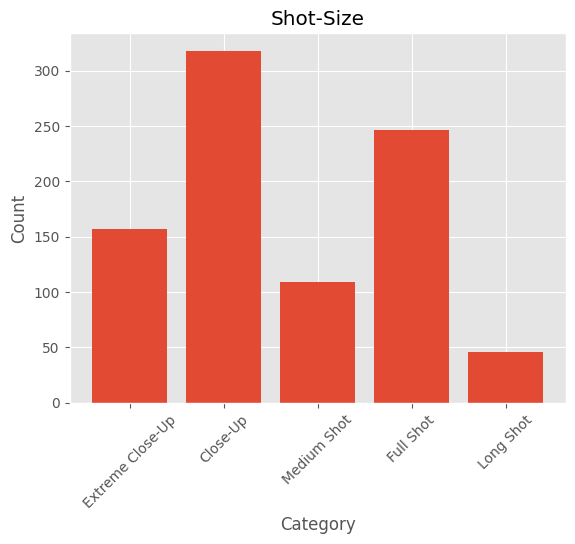

In [6]:
import matplotlib.pyplot as plt
# plt.style.use("seaborn-v0_8-whitegrid")
plt.style.use("ggplot")

labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=1

plt.bar(labels, values)
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

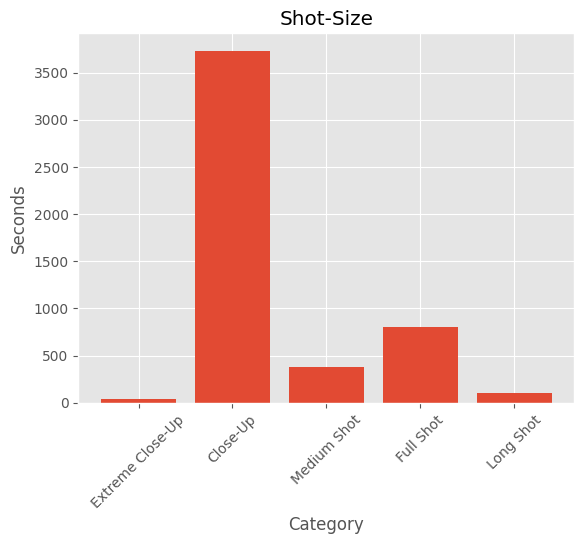

In [7]:
labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0.0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=shot_start_end[label_index][1] - shot_start_end[label_index][0]

plt.bar(labels, values)
plt.xlabel("Category")
plt.ylabel("Seconds")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

# Read Face Clustering Data Information
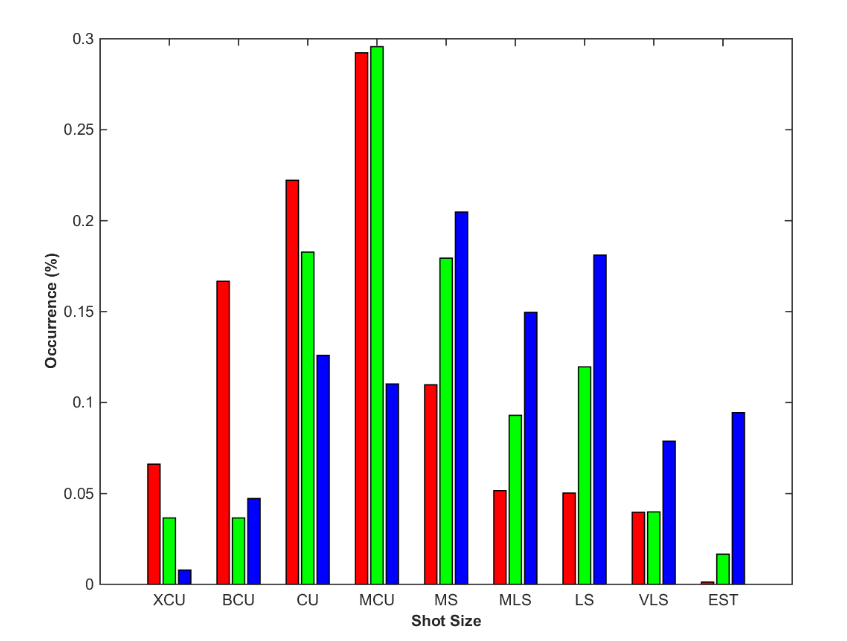

In [8]:
# init the result entry
shot_face_count = {
    "Extreme Close-Up":[0,0,0],
    "Close-Up":[0,0,0],
    "Medium Shot":[0,0,0],
    "Full Shot":[0,0,0],
    "Long Shot":[0,0,0]
}

for x in os.listdir("data/"):
  print(f"#### {x}")


  movie_shot_annotations = []
  movie_shot_start_end = []

  for data in data_iterator(os.path.join("data", x)):
    if data.type == "AnnotationData":
      for anno in data.annotations:
        for label in anno.labels:
          if "Shot Size::" in label:
            movie_shot_annotations.append(label.split("Shot Size::")[-1])
            movie_shot_start_end.append([anno.start, anno.end])


  faces = {}
  for data in data_iterator(os.path.join("data", x)):
      if data.type == "FacesData":
          for face in data.faces:
              faces[face.id]={}

  embeddings_map = {}
  for data in data_iterator(os.path.join("data", x)):
      if data.type == "ImageEmbeddings":
          for emb in data.embeddings:
              embeddings_map[emb.id] = emb.ref_id
              faces[emb.ref_id]["time"] = emb.time
      if data.type == "BboxesData":
          for bbox in data.bboxes:
              faces[bbox.ref_id]["bbox"] = bbox.to_dict()


  for data in data_iterator(os.path.join("data", x)):
      if data.type == "ClusterData":
          for i, cluster in enumerate(data.clusters):
              for id in cluster.embedding_ids:
                  faces[embeddings_map[id]]["cluster"] = i

  for index, [shot_start, shot_end] in enumerate(movie_shot_start_end):
      shot_faces = set()
      for face in faces.values():
          if shot_start<face["time"] and face["time"] < shot_end and "cluster" in face:
              shot_faces.add(face["cluster"])

      anno = movie_shot_annotations[index]

      # distinction based on the number of faces
      if len(shot_faces) == 1:
          shot_face_count[anno][0] +=1
      if len(shot_faces) == 2:
          shot_face_count[anno][1] +=1
      if len(shot_faces) > 2:
          shot_face_count[anno][2] +=1


#### american_history_x.zip
#### benjamin.zip
#### big_fish.zip
#### forrest.zip
#### gattaca_1.zip
#### gattaca_2.zip
#### godfather.zip
#### good_bad_ugly.zip
#### hunger_games_1.zip
#### hunger_games_2.zip
#### invictus.zip
#### lotr.zip
#### pulp_fiction.zip
#### shawshank_1.zip
#### shawshank_2.zip
#### shining.zip
#### the_help_1.zip
#### big_fish_fix.zip
#### forrest_fix.zip
#### gattaca_2_fix.zip
#### godfather_fix.zip
#### invictus_fix.zip
#### pulp_fiction_fix.zip
#### shining_fix.zip


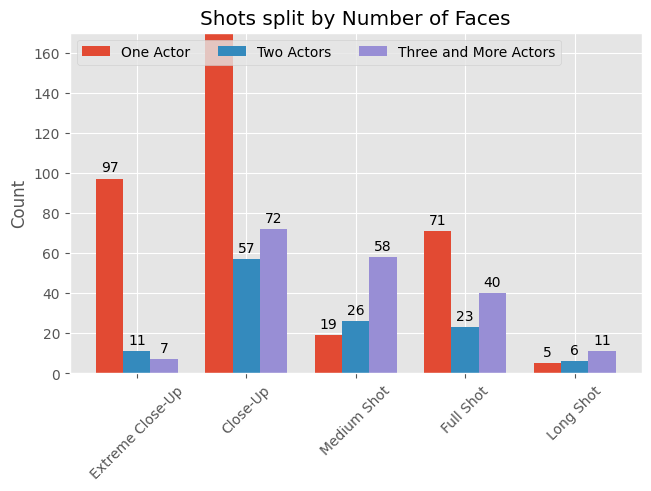

In [9]:
import numpy as np


x = np.arange(len(shot_face_count))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for num_faces, label in enumerate(["One Actor", "Two Actors", "Three and More Actors"]):
    offset = width * multiplier
    rects = ax.bar(x + offset, [x[num_faces] for x in shot_face_count.values()], width, label=label)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Shots split by Number of Faces')
ax.set_xticks(x + width, shot_face_count.keys())
ax.legend(loc='upper left', ncols=3)

plt.xticks(rotation=45)
ax.set_ylim(0, 170)

plt.show()

# Shot Length Distribution by Shot Size

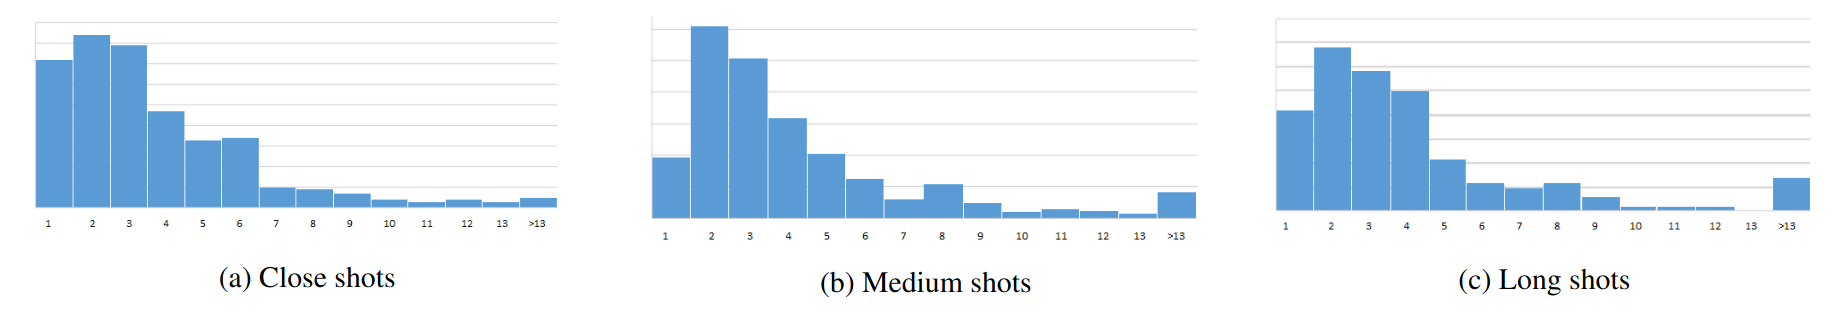


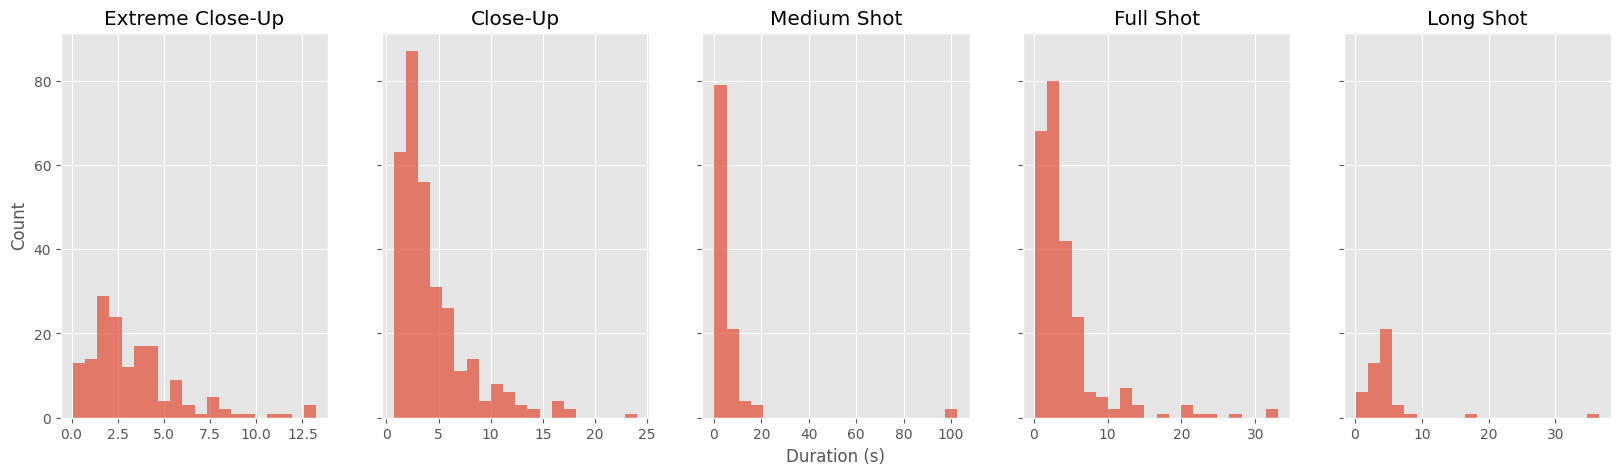

In [10]:
labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [[] for x in labels]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)

for i, size in enumerate(labels):
    for j, anno in enumerate(shot_annotations):
        
        if size == anno:
            values[i].append(shot_start_end[j][1] - shot_start_end[j][0])
    #print(values[i])
    axes[i].hist(values[i], bins=20, alpha=0.7, label=size)
    
    axes[i].set_title(size)
axes[2].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
plt.show()

# Shot Length Distribution by Number of Faces
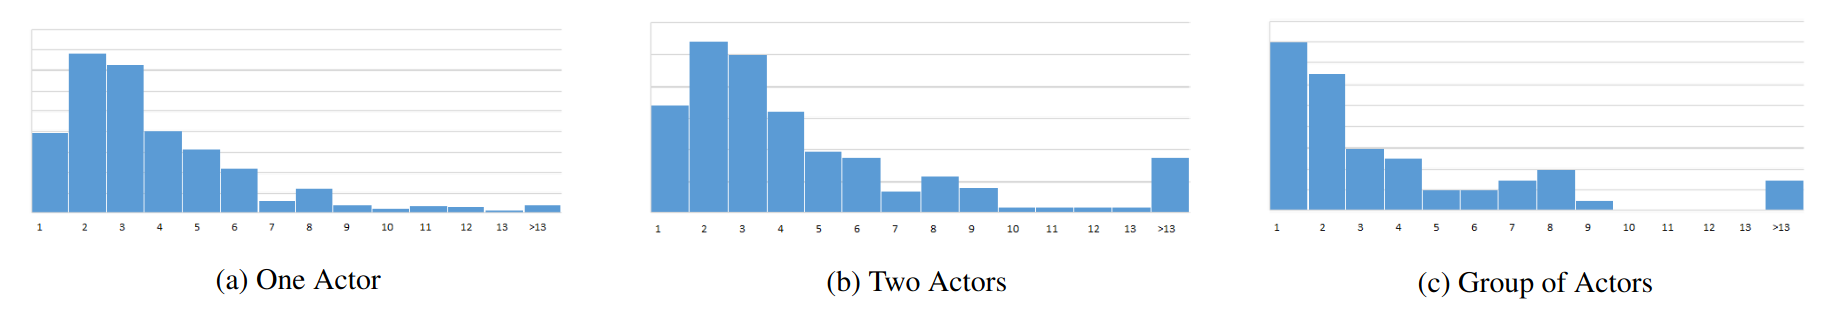

In [11]:
# init the result entry
face_duration = [
    [], 
    [], 
    []
]

for x in os.listdir("data/"):
  print(f"#### {x}")


  movie_shot_annotations = []
  movie_shot_start_end = []

  for data in data_iterator(os.path.join("data", x)):
    if data.type == "AnnotationData":
      for anno in data.annotations:
        for label in anno.labels:
          if "Shot Size::" in label:
            movie_shot_annotations.append(label.split("Shot Size::")[-1])
            movie_shot_start_end.append([anno.start, anno.end])


  faces = {}
  for data in data_iterator(os.path.join("data", x)):
      if data.type == "FacesData":
          for face in data.faces:
              faces[face.id]={}

  embeddings_map = {}
  for data in data_iterator(os.path.join("data", x)):
      if data.type == "ImageEmbeddings":
          for emb in data.embeddings:
              embeddings_map[emb.id] = emb.ref_id
              faces[emb.ref_id]["time"] = emb.time
      if data.type == "BboxesData":
          for bbox in data.bboxes:
              faces[bbox.ref_id]["bbox"] = bbox.to_dict()


  for data in data_iterator(os.path.join("data", x)):
      if data.type == "ClusterData":
          for i, cluster in enumerate(data.clusters):
              for id in cluster.embedding_ids:
                  faces[embeddings_map[id]]["cluster"] = i

  for index, [shot_start, shot_end] in enumerate(movie_shot_start_end):
      shot_faces = set()
      for face in faces.values():
          if shot_start<face["time"] and face["time"] < shot_end and "cluster" in face:
              shot_faces.add(face["cluster"])

      anno = movie_shot_annotations[index]
      

      # distinction based on the number of faces
      if len(shot_faces) == 1:
          face_duration[0].append(shot_end- shot_start)
      if len(shot_faces) == 2:
          face_duration[1].append(shot_end- shot_start)
      if len(shot_faces) > 2:
          face_duration[2].append(shot_end- shot_start)



#### american_history_x.zip
#### benjamin.zip
#### big_fish.zip
#### forrest.zip
#### gattaca_1.zip
#### gattaca_2.zip
#### godfather.zip
#### good_bad_ugly.zip
#### hunger_games_1.zip
#### hunger_games_2.zip
#### invictus.zip
#### lotr.zip
#### pulp_fiction.zip
#### shawshank_1.zip
#### shawshank_2.zip
#### shining.zip
#### the_help_1.zip
#### big_fish_fix.zip
#### forrest_fix.zip
#### gattaca_2_fix.zip
#### godfather_fix.zip
#### invictus_fix.zip
#### pulp_fiction_fix.zip
#### shining_fix.zip


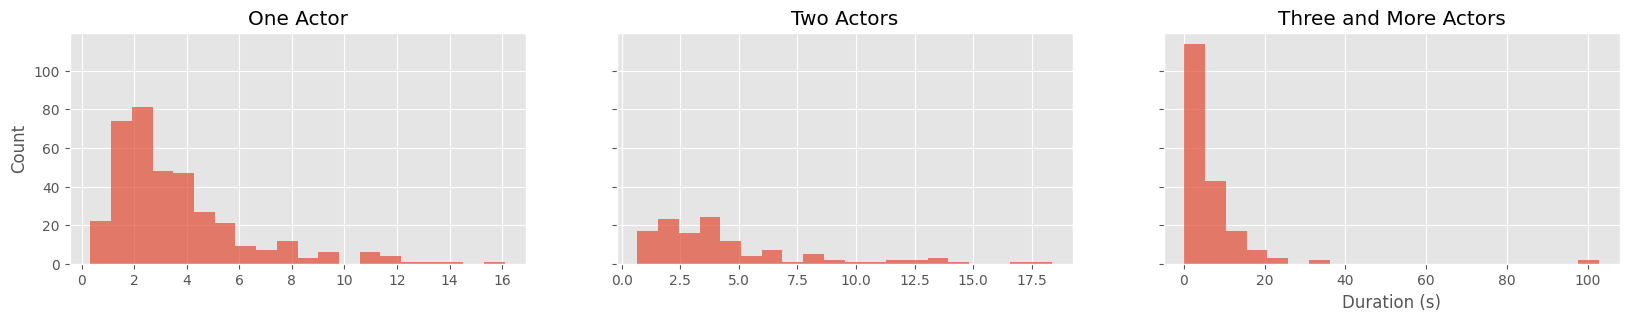

In [12]:
labels = ["One Actor", "Two Actors", "Three and More Actors"]
fig, axes = plt.subplots(1, 3, figsize=(20, 3), sharey=True)

for i, size in enumerate(labels):
    axes[i].hist(face_duration[i], bins=20, alpha=0.7, label=size)
    
    axes[i].set_title(size)
axes[2].set_xlabel("Duration (s)")
axes[0].set_ylabel("Count")
plt.show()